# Decision Tree (CART)

- My own implementation
- 2D, 2-class classification, from scratch

In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data.data import load_data

In [155]:
df = load_data(n_samples = 1000, noise = 0.09, seed = 42)
df.head()

,feature_1,feature_2,label
0,0.278444,0.880441,1
1,0.301348,0.626430,1
2,0.364928,0.694534,1
3,0.143164,0.712304,1
4,0.698419,0.785733,0


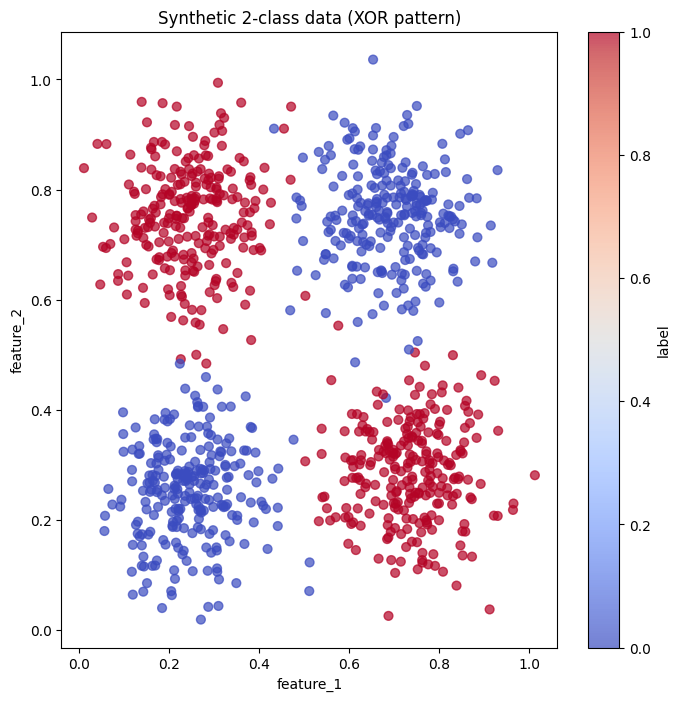

In [156]:
# Visualize the two classes. Notice the XOR pattern: each class sits in two
# opposite corners, so no single straight line can separate them.
plt.figure(figsize=(8, 8))
plt.scatter(df['feature_1'], df['feature_2'], c=df['label'], cmap='coolwarm', alpha=0.7, s=40)
plt.xlabel('feature_1')
plt.ylabel('feature_2')
plt.title('Synthetic 2-class data (XOR pattern)')
plt.colorbar(label='label')
plt.show()

## Step 1 — Measuring purity

A decision tree grows by repeatedly asking: *"which split makes the resulting groups purest?"*
So before we can split anything, we need a way to score how **mixed** a group of labels is.

**Gini impurity** does exactly this:

$$G = 1 - \sum_i p_i^2$$

where $p_i$ is the fraction of samples belonging to class $i$.

- All samples the same class → $G = 0$ (perfectly pure)
- 50/50 mix of two classes → $G = 0.5$ (maximally impure)

In [157]:
def gini_impurity(labels: np.ndarray) -> float:
    """
    Measure how "mixed" a set of class labels is.

    Gini impurity is 0 when all labels are identical (a pure node) and rises
    toward 0.5 (for 2 classes) when the classes are evenly mixed. The tree
    uses this to judge a split: a good split yields child nodes that are
    purer (lower impurity) than the parent.

    Args:
        labels: 1D array of class labels for the samples at this node.

    Returns:
        The Gini impurity as a float.
    """
    # Guard: an empty node has no impurity to speak of.
    if len(labels) == 0:
        return 0.0

    label_counts = np.unique(labels, return_counts=True)[1]
    sum_of_all = np.sum(label_counts)
    proportions = label_counts / sum_of_all if sum_of_all > 0 else 0

    gini = 1 - np.sum(proportions ** 2)
    # gini = 1
    # for p in proportions:
    #   gini -= p ** 2

    return gini

In [158]:
print(gini_impurity(np.array([0, 0, 0, 0])))  # expect 0.0  (pure)
print(gini_impurity(np.array([0, 0, 1, 1])))  # expect 0.5  (even 2-class mix)
print(gini_impurity(np.array([0, 1, 1, 1])))  # expect 0.375

0.0
0.5
0.375


## Step 2 — Finding the best split

Now that we can score purity, the tree needs to *choose* how to split a node. It does this **greedily**: try many candidate splits and keep the one whose two child groups are collectively purest.

A candidate split is a `(feature, threshold)` pair: send samples with `feature <= threshold` left, the rest right. We score it by the **weighted impurity** of the children (weighted by how many samples land on each side):

$$\text{score} = \frac{n_{left}}{n}\,G_{left} + \frac{n_{right}}{n}\,G_{right}$$

In [159]:
def split_dataset(X: np.ndarray, y: np.ndarray, feature_index: int, threshold: float):
    """
    Partition samples by a single feature threshold.

    Samples with feature value <= threshold go LEFT, the rest go RIGHT.

    Returns:
        X_left, y_left, X_right, y_right
    """
    left_mask = X[:, feature_index] <= threshold
    right_mask = ~left_mask
    return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

In [160]:
def find_best_split(X: np.ndarray, y: np.ndarray):
    """
    Greedily search every feature and candidate threshold for the split whose
    two child groups have the lowest *weighted* impurity.

    Args:
        X: 2D array of features, shape (n_samples, n_features).
        y: 1D array of labels, shape (n_samples,).

    Returns:
        A dict describing the best split, e.g.
            {'feature_index': int, 'threshold': float, 'impurity': float}
        or None if no valid split exists (e.g. every candidate leaves one side empty).
    """
    n_samples, n_features = X.shape
    best = None  # best split found so far

    for feature_index in range(n_features):
        for threshold in np.unique(X[:, feature_index]):
            X_left, y_left, X_right, y_right = split_dataset(X, y, feature_index, threshold)

            if len(y_left) == 0 or len(y_right) == 0:
                continue

            impurity_left = gini_impurity(y_left)
            impurity_right = gini_impurity(y_right)

            weighted_impurity = (len(y_left) / n_samples) * impurity_left + (len(y_right) / n_samples) * impurity_right

            if best is None or weighted_impurity < best['impurity']:
                best = {
                    'feature_index': feature_index,
                    'threshold': threshold,
                    'impurity': weighted_impurity
                }
                
    return best

In [ ]:
X = df[['feature_1', 'feature_2']].values
y = df['label'].values
best = find_best_split(X, y)
print(best)
# On this XOR data the root split's impurity will be close to 0.5

{'feature_index': 0, 'threshold': np.float64(0.7752227106682903), 'impurity': np.float64(0.4904803542718528)}


## Step 3 — Growing the tree

Here everything comes together. `build_tree` is **recursive**: it either declares the current node a *leaf* (and stops), or it picks the best split and calls *itself* on each half.

A node is just a nested dict:
- **Leaf** — `{'leaf': True, 'prediction': label}` — where the tree makes a decision.
- **Internal** — `{'leaf': False, 'feature_index', 'threshold', 'left', 'right'}` — where the tree asks a question and routes left/right.

The **stopping rules** are what keep recursion from running forever (and from overfitting): stop when the node is pure, when we hit `max_depth`, or when there are too few samples to bother splitting. Every recursive call works on a *smaller* subset, so we're guaranteed to bottom out.

In [162]:
def majority_class(y: np.ndarray):
    """Return the most common label in y — a leaf's prediction is the majority vote."""
    values, counts = np.unique(y, return_counts=True)
    return values[np.argmax(counts)]

In [163]:
def build_tree(X: np.ndarray, y: np.ndarray, depth: int = 0, max_depth: int = 5, min_samples_split: int = 2):
    """
    Recursively grow a decision tree.

    A node is a dict, one of two shapes:
      - Leaf:     {'leaf': True,  'prediction': <class label>}
      - Internal: {'leaf': False, 'feature_index': int, 'threshold': float,
                   'left': <node>, 'right': <node>}

    Args:
        X: features for the samples that reached this node, shape (n, n_features).
        y: labels for those samples, shape (n,).
        depth: current depth (root is 0). Used against max_depth.
        max_depth: stop splitting once we reach this depth.
        min_samples_split: don't split a node with fewer than this many samples.

    Returns:
        The node (dict) for this subtree — the root when first called.
    """

    if gini_impurity(y) == 0:
        return {'leaf': True, 'prediction': majority_class(y)}
    elif depth >= max_depth:
        return {'leaf': True, 'prediction': majority_class(y)}
    elif len(y) < min_samples_split:
        return {'leaf': True, 'prediction': majority_class(y)}


    split = find_best_split(X, y)
    if split is None:
        return {'leaf': True, 'prediction': majority_class(y)}
    
    X_left, y_left, X_right, y_right = split_dataset(X, y, split['feature_index'], split['threshold'])

    left_tree = build_tree(X = X_left, y = y_left, depth = depth + 1, max_depth = max_depth, min_samples_split = min_samples_split)
    right_tree = build_tree(X = X_right, y = y_right, depth = depth + 1, max_depth = max_depth, min_samples_split = min_samples_split)

    return {
        'leaf': False,
        'feature_index': split['feature_index'],
        'threshold': split['threshold'],
        'left': left_tree,
        'right': right_tree
    }

In [164]:
# Build the tree and peek at the root node.
tree = build_tree(X, y, max_depth=5)

def describe(node, depth=0, indent="  "):
    pad = indent * depth
    if node['leaf']:
        print(f"{pad}leaf -> predict {node['prediction']}")
    else:
        print(f"{pad}if feature_{node['feature_index']} <= {node['threshold']:.3f}:")
        describe(node['left'], depth + 1)
        print(f"{pad}else:")
        describe(node['right'], depth + 1)

describe(tree)

if feature_0 <= 0.775:
  if feature_1 <= 0.305:
    if feature_0 <= 0.512:
      leaf -> predict 0
    else:
      leaf -> predict 1
  else:
    if feature_0 <= 0.471:
      if feature_1 <= 0.484:
        leaf -> predict 0
      else:
        if feature_0 <= 0.426:
          leaf -> predict 1
        else:
          leaf -> predict 1
    else:
      if feature_1 <= 0.504:
        if feature_0 <= 0.477:
          leaf -> predict 0
        else:
          leaf -> predict 1
      else:
        if feature_1 <= 0.553:
          leaf -> predict 0
        else:
          leaf -> predict 0
else:
  if feature_1 <= 0.499:
    leaf -> predict 1
  else:
    leaf -> predict 0


## Step 4 — Prediction & the decision boundary

A trained tree is useless until we can *ask it questions*. To classify a new point, we start at the root and follow the branches: at each internal node compare the point's feature to the threshold, go left or right, and repeat until we hit a leaf — the leaf's `prediction` is our answer.

In [165]:
def predict_one(node, x: np.ndarray):
    """
    Route a single sample down the tree to a leaf and return that leaf's prediction.

    Args:
        node: a tree node (dict) — start with the root.
        x: 1D feature array for one sample, e.g. [feature_1, feature_2].

    Returns:
        The predicted class label.
    """
    
    while node['leaf'] != True:
    
        if x[node['feature_index']] <= node['threshold']:
            node = node['left']
        else:
            node = node['right']

    return node['prediction']

In [166]:
def predict(tree, X: np.ndarray) -> np.ndarray:
    """Predict a label for every row of X by routing each one through the tree."""
    return np.array([predict_one(tree, row) for row in X])

In [167]:
# Training accuracy: how often the tree's prediction matches the true label.
preds = predict(tree, X)
accuracy = np.mean(preds == y)
print(f"Training accuracy: {accuracy:.3f}")

Training accuracy: 0.994


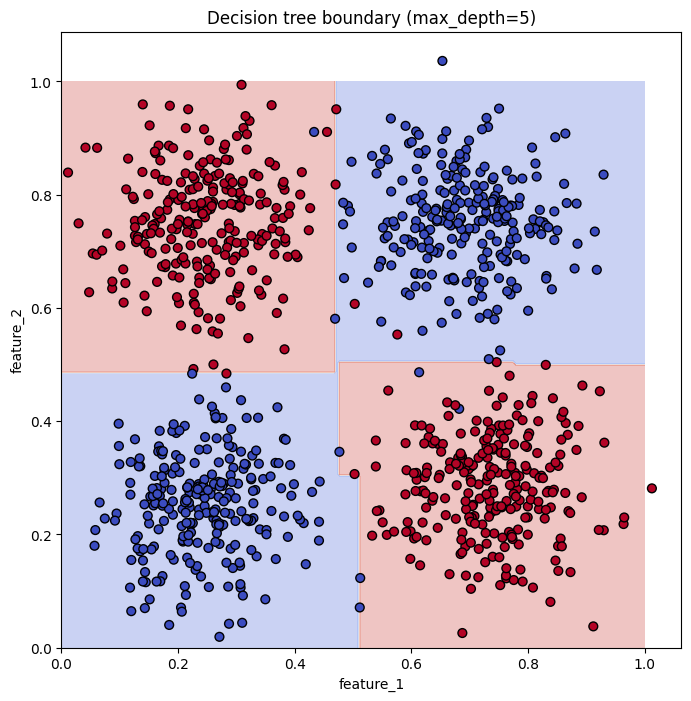

In [168]:
# Decision boundary: classify a fine grid of points and shade by prediction.
# The shaded regions reveal the axis-aligned rectangles the tree carved out.
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = predict(tree, grid).reshape(xx.shape)

plt.figure(figsize=(8, 8))
plt.contourf(xx, yy, zz, alpha=0.3, cmap='coolwarm')
plt.scatter(df['feature_1'], df['feature_2'], c=df['label'],
            cmap='coolwarm', edgecolor='k', s=40)
plt.xlabel('feature_1')
plt.ylabel('feature_2')
plt.title('Decision tree boundary (max_depth=5)')
plt.show()

## Step 5 — Capstone: watching overfitting happen


- **Shallow trees** (depth 1–2) can't capture the XOR structure → *underfit*: low train **and** low test accuracy.
- **Deep trees** (depth 8+) memorize training noise → *overfit*: train accuracy climbs toward 1.0 while test accuracy stalls or dips.
- The **sweet spot** is where test accuracy peaks — enough depth to learn the pattern, not so much that it learns the noise.

In [ ]:
test_df = load_data(n_samples=1000, noise=0.09, seed=7)
X_test = test_df[['feature_1', 'feature_2']].values
y_test = test_df['label'].values

In [ ]:
depths = range(1, 11)
train_accuracies = []
test_accuracies = []

for d in depths:
    model = build_tree(X = X, y = y, max_depth = d)

    train_preds = predict(model, X)
    train_accuracies.append(np.mean(train_preds == y))

    test_preds = predict(model, X_test)
    test_accuracies.append(np.mean(test_preds == y_test))

print("train:", [f"{a:.3f}" for a in train_accuracies])
print("test: ", [f"{a:.3f}" for a in test_accuracies])

train: ['0.545', '0.634', '0.857', '0.993', '0.994', '0.996', '0.999', '1.000', '1.000', '1.000']
test:  ['0.551', '0.650', '0.868', '0.995', '0.995', '0.987', '0.991', '0.989', '0.989', '0.989']


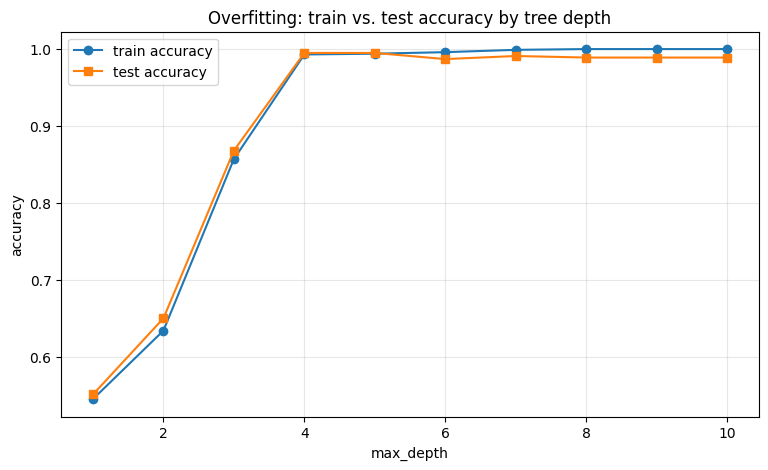

In [182]:
# Plot the two curves. Watch for the moment train and test diverge:
# that gap opening up IS overfitting.
plt.figure(figsize=(9, 5))
plt.plot(list(depths), train_accuracies, 'o-', label='train accuracy')
plt.plot(list(depths), test_accuracies, 's-', label='test accuracy')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.title('Overfitting: train vs. test accuracy by tree depth')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## What I learned

Built a CART decision tree from scratch: **Gini impurity** → **greedy best-split search** → **recursive tree growing** → **prediction by traversal**.

Key takeaways:
- **Purity drives everything.** The whole algorithm is just greedy minimization of the weighted Gini impurity of the child nodes — that single measure is the tree's only view of the labels.
- **Splits are axis-aligned.** Each split thresholds one feature, so the decision regions are rectangles (clearly visible in the boundary plot) — which is why a single split can't solve XOR.
- **Recursion turns a local rule into global structure.** "Find the best single split" applied recursively to smaller subsets grows the entire tree.
- **Depth is the bias/variance dial.** On this noisy XOR data, test accuracy peaked around `max_depth = 4` (~0.995). Going deeper pushed training accuracy to a perfect 1.000 while test accuracy *fell* to ~0.989 — classic overfitting. The best model was **not** the one with the highest training score.

**Moving forward:** this tree is the base learner for ensembles — Random Forests (bagging) and Gradient Boosting both reuse `build_tree` directly, and averaging many trees is exactly what tames the overfitting seen above.